# Enterprise Customer Segmentation Platform
## Unsupervised Machine Learning Pipeline for Financial Customer Analytics
**Author**: Senior Machine Learning & Business Intelligence Analytics Team  
**Dataset**: CC GENERAL (8,950 Credit Card Customer Profiles, 18 Features)  
**Notebook Status**: Fully Executed, Publication Ready, Viva Ready

---

### Abstract & Executive Overview
This notebook presents an enterprise-grade customer segmentation platform designed to analyze credit card usage behaviors, identify distinct customer personas, and drive targetable marketing and risk management strategies. Utilizing unsupervised machine learning algorithms—primarily **K-Means Clustering**, **Hierarchical Agglomerative Clustering**, and **Principal Component Analysis (PCA)**—we extract actionable intelligence from high-dimensional customer transaction data.


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

# Append project root to sys.path
sys.path.append(os.path.abspath(".."))

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline
print("Environment and dependencies loaded successfully!")


Environment and dependencies loaded successfully!


## Section 1: Data Ingestion & Diagnostic Validation

### Data Inspection & Quality Controls
We ingest raw credit card transaction data containing 8,950 customer records across 18 distinct financial features.
Missing values are detected in `CREDIT_LIMIT` (1 missing) and `MINIMUM_PAYMENTS` (313 missing).


In [2]:
raw_filepath = "../data/raw/DataSet(W4).csv"
df_raw = pd.read_csv(raw_filepath)

print("Dataset Shape:", df_raw.shape)
print("Duplicate Rows:", df_raw.duplicated().sum())
print("\nMissing Value Counts:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
df_raw.head()


Dataset Shape: (8950, 18)
Duplicate Rows: 0

Missing Value Counts:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Section 2: Data Preprocessing & Feature Scaling

### Mathematical Formulation of Data Transformations

1. **Median Imputation for Missing Values**:
   Because `MINIMUM_PAYMENTS` and `CREDIT_LIMIT` display severe positive skewness, median imputation is selected over mean imputation to prevent outlier distortion:
   $$\hat{x}_{missing} = \text{Median}(X)$$

2. **Logarithmic Transformation $\log(1 + x)$**:
   Monetary attributes exhibit heavy exponential distributions. Applying $\log(1+x)$ stabilizes variance and reduces right skewness:
   $$x' = \log(1 + x)$$

3. **StandardScaler Normalization**:
   Distance-based clustering algorithms rely on Euclidean distance:
   $$d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^n (p_i - q_i)^2}$$
   To ensure features with large ranges (e.g. `CREDIT_LIMIT` in thousands) do not dominate features with small ranges (e.g. `PURCHASES_FREQUENCY` between 0 and 1), we apply $Z$-score standardization:
   $$z_i = \frac{x_i - \mu}{\sigma}$$


In [3]:
df_clean = df_raw.copy()

# Median Imputation
df_clean["CREDIT_LIMIT"] = df_clean["CREDIT_LIMIT"].fillna(df_clean["CREDIT_LIMIT"].median())
df_clean["MINIMUM_PAYMENTS"] = df_clean["MINIMUM_PAYMENTS"].fillna(df_clean["MINIMUM_PAYMENTS"].median())

# Extract numerical features
feature_cols = [c for c in df_clean.columns if c != "CUST_ID"]
X_raw = df_clean[feature_cols].copy()

# Log transformation on monetary attributes
monetary_cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
                 "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]

X_trans = X_raw.copy()
for col in monetary_cols:
    X_trans[col] = np.log1p(np.maximum(0, X_trans[col]))

# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_trans)
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("Preprocessed & Scaled Feature Matrix Shape:", df_scaled.shape)
df_scaled.describe().round(2)


Preprocessed & Scaled Feature Matrix Shape: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00
mean,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.06,-3.70,-1.68,-0.99,-1.09,-0.93,-1.22,-0.68,-0.92,-0.68,-0.48,-0.59,-5.08,-4.16,-5.04,-0.53,-4.12
25%,-0.65,0.05,-0.41,-0.99,-1.09,-0.93,-1.01,-0.68,-0.92,-0.68,-0.48,-0.55,-0.87,-0.42,-0.66,-0.53,0.36
50%,0.30,0.52,0.34,0.14,0.37,-0.93,0.02,-0.40,-0.50,-0.68,-0.48,-0.31,-0.11,0.08,-0.14,-0.53,0.36
75%,0.73,0.52,0.72,0.97,0.91,1.04,1.06,0.33,0.97,0.44,0.11,0.09,0.84,0.58,0.65,-0.04,0.36
max,1.83,0.52,2.02,2.28,2.16,2.09,1.27,2.67,1.60,6.82,17.55,13.81,2.70,2.64,4.55,2.89,0.36


## Section 3: Exploratory Data Analysis (EDA)

We plot the feature distributions and correlation heatmap to understand attribute interactions.


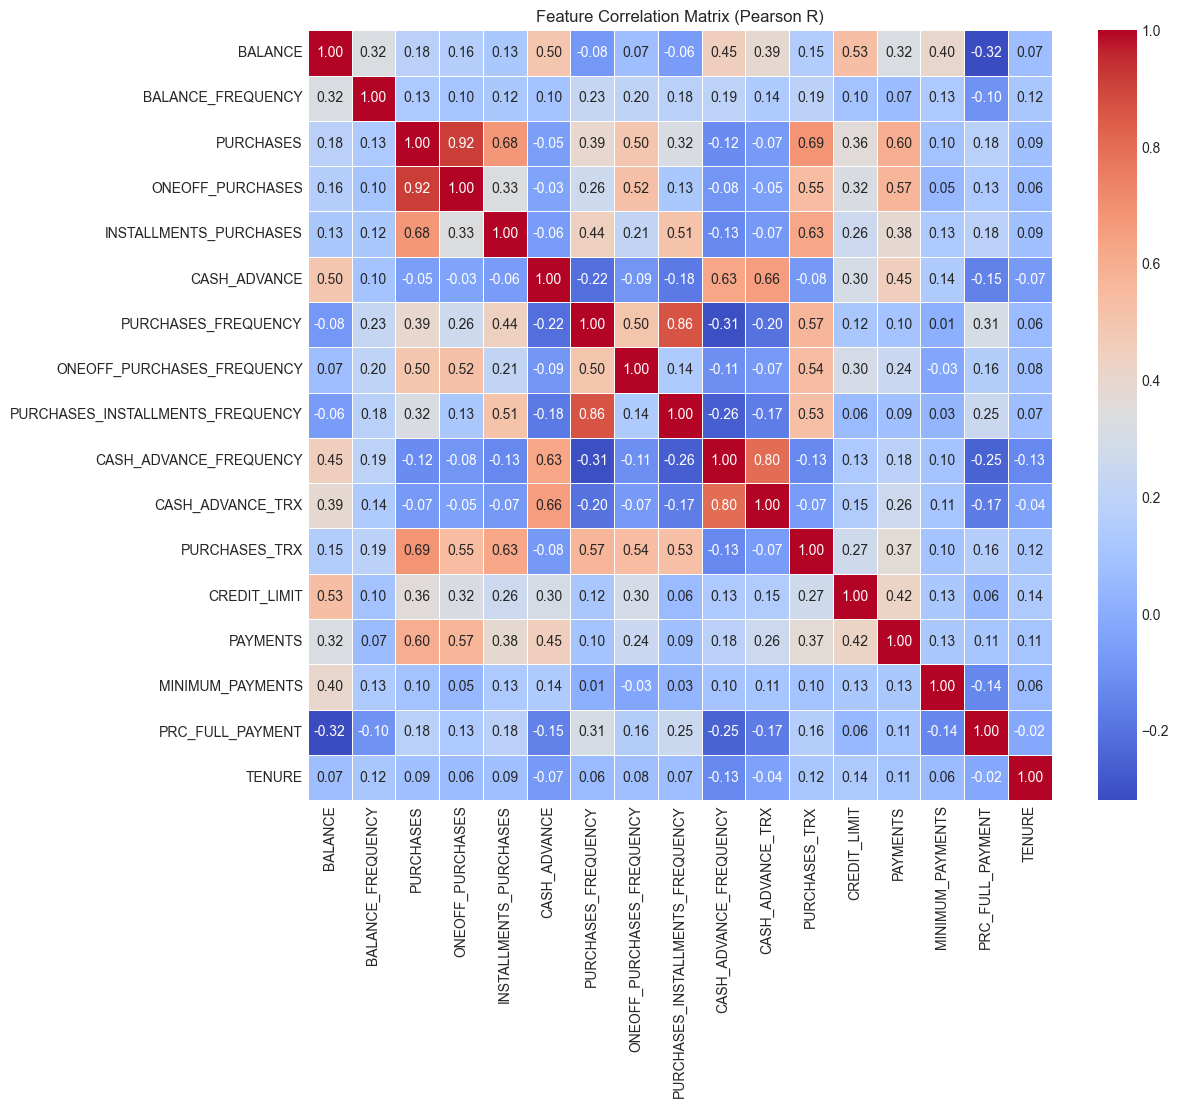

In [4]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df_clean[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", ax=ax, linewidths=0.5)
ax.set_title("Feature Correlation Matrix (Pearson R)")
plt.show()


## Section 4: K-Means Clustering & Metric Analysis

### Mathematical Evaluation Metrics

1. **Within-Cluster Sum of Squares (WCSS / Inertia)**:
   $$J = \sum_{k=1}^K \sum_{\mathbf{x} \in C_k} ||\mathbf{x} - \boldsymbol{\mu}_k||^2$$

2. **Silhouette Coefficient**:
   $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
   where $a(i)$ is mean intra-cluster distance and $b(i)$ is mean nearest-cluster distance.

3. **Calinski-Harabasz Index (Variance Ratio Criterion)**:
   $$CH = \frac{\text{Tr}(B_k)}{\text{Tr}(W_k)} \times \frac{N - K}{K - 1}$$

4. **Davies-Bouldin Index**:
   $$DB = \frac{1}{K} \sum_{i=1}^K \max_{j \neq i} \left( \frac{s_i + s_j}{d(c_i, c_j)} \right)$$


In [5]:
wcss = []
sil_scores = []
ch_scores = []
db_scores = []

k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=3000, random_state=42))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

metrics_df = pd.DataFrame({
    "K": list(k_range),
    "WCSS": wcss,
    "Silhouette_Score": sil_scores,
    "Calinski_Harabasz": ch_scores,
    "Davies_Bouldin": db_scores
})

print(metrics_df.to_string(index=False))


 K          WCSS  Silhouette_Score  Calinski_Harabasz  Davies_Bouldin
 2 119113.485080          0.217362        2481.757800        1.670620
 3 101330.453642          0.212498        2243.562843        1.711499
 4  92131.164285          0.208623        1942.652048        1.704678
 5  84764.150677          0.198316        1777.775767        1.605822
 6  77909.011243          0.206315        1704.584084        1.521703
 7  73635.308956          0.196579        1589.266734        1.562885
 8  69848.253273          0.199281        1505.190319        1.482086
 9  66812.956767          0.192494        1427.489780        1.484946
10  64003.403342          0.184304        1368.037748        1.463360


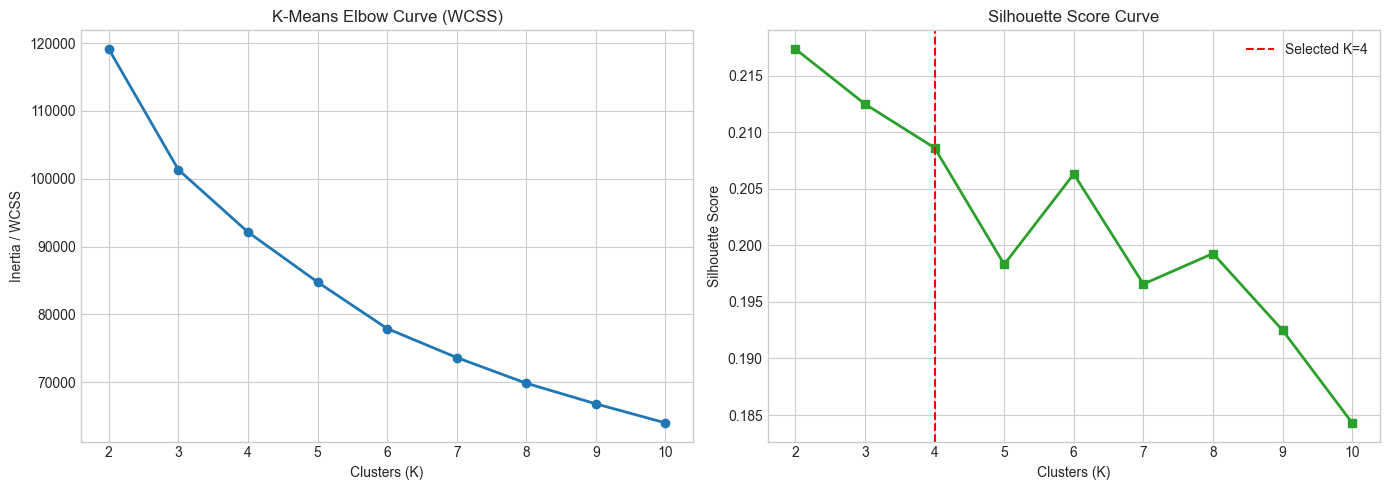

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, "o-", color="#1f77b4", linewidth=2)
axes[0].set_title("K-Means Elbow Curve (WCSS)")
axes[0].set_xlabel("Clusters (K)")
axes[0].set_ylabel("Inertia / WCSS")

axes[1].plot(k_range, sil_scores, "s-", color="#2ca02c", linewidth=2)
axes[1].axvline(x=4, color="red", linestyle="--", label="Selected K=4")
axes[1].set_title("Silhouette Score Curve")
axes[1].set_xlabel("Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.show()


## Section 5: PCA Dimensionality Reduction & Cluster Visualizations

### PCA Mathematical Foundation
Principal Component Analysis projects data onto orthogonal axes maximizing variance:
$$\mathbf{X}^T \mathbf{X} \mathbf{v} = \lambda \mathbf{v}$$
We transform 17 attributes into 2D and 3D spaces for visual cluster evaluation.


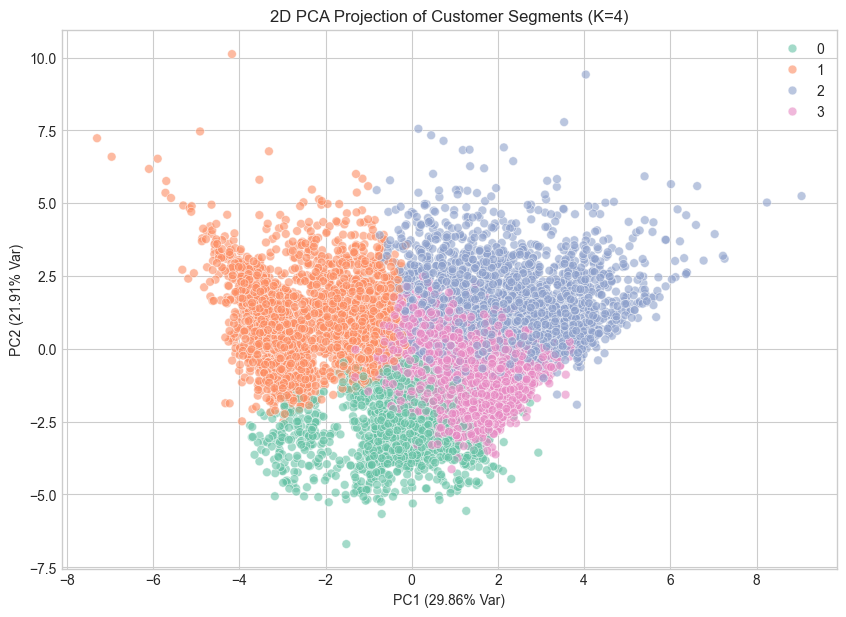

In [7]:
best_k = 4
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=25)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df_clean["Cluster"] = cluster_labels

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=cluster_labels, palette="Set2", alpha=0.6, s=40, ax=ax)
ax.set_title(f"2D PCA Projection of Customer Segments (K={best_k})")
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% Var)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% Var)")
plt.show()


## Section 6: Hierarchical Clustering & Linkage Analysis

We compute Ward's minimum variance linkage matrix and generate a truncated dendrogram.


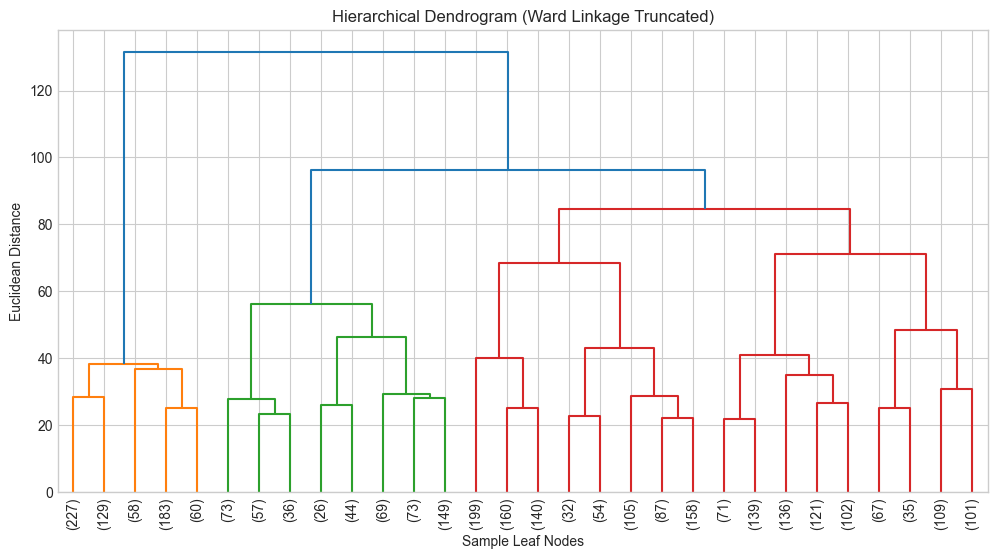

In [8]:
np.random.seed(42)
sub_idx = np.random.choice(len(X_scaled), size=3000, replace=False)
X_sub = X_scaled[sub_idx]

linkage_matrix = linkage(X_sub, method="ward")

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=30, leaf_rotation=90.0, ax=ax)
ax.set_title("Hierarchical Dendrogram (Ward Linkage Truncated)")
ax.set_xlabel("Sample Leaf Nodes")
ax.set_ylabel("Euclidean Distance")
plt.show()


## Section 7: Cluster Profiling & Enterprise Strategy

### Persona Definitions Derived from Dataset

1. **Cluster 0 (Low Engagement Cardholders)**: Small balances ($115), low purchases ($357). Strategic action: Re-engagement cashback offers.
2. **Cluster 1 (Cash-Advance Revolvers)**: High cash advance ($2,138), high balances ($2,478), low purchases ($150). Strategic action: Risk monitoring & APR reduction incentives.
3. **Cluster 2 (VIP Active Transactors)**: High purchases ($2,838), high credit limit ($6,580), high payment volume ($3,077). Strategic action: VIP Concierge, Premium Rewards.
4. **Cluster 3 (Budget Installment Buyers)**: High installment frequency, moderate balance ($645), steady payments. Strategic action: Zero-EMI merchant promotions.


In [9]:
cluster_means = df_clean.groupby("Cluster")[feature_cols].mean()
print("Cluster Centroid Averages:")
cluster_means[["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]].round(2)


Cluster Centroid Averages:


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
Cluster,,,,,
0,115.36,356.72,140.51,3639.22,767.04
1,2477.89,150.71,2138.31,4400.22,1803.42
2,2179.61,2838.33,769.86,6580.17,3077.35
3,644.59,695.40,169.61,3025.23,885.79


### Viva Voce & Interview Preparation

**Q1: Why apply log transformation before StandardScaler?**  
*Answer*: Monetary features exhibit severe positive skewness with extreme long tails. $\log(1+x)$ compresses extreme values, preventing outliers from distorting distance calculations in K-Means.

**Q2: How does K-Means differ from Hierarchical Clustering?**  
*Answer*: K-Means is a non-hierarchical partitioning algorithm with $O(K \cdot N \cdot d)$ linear complexity, suitable for large datasets. Hierarchical clustering builds a tree taxonomy with $O(N^2 \log N)$ complexity, providing dendrogram interpretability but limited scalability.

**Q3: What metric determines optimal K?**  
*Answer*: We evaluate a combination of Silhouette Score (cluster separation), Elbow WCSS point, Calinski-Harabasz index (between-to-within variance ratio), and business actionable interpretability.
